In [7]:
# pip install -U pypdfium2

In [6]:
# pip install -q openpyxl

Note: you may need to restart the kernel to use updated packages.


In [28]:
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
import boto3
import base64
import json
import tempfile
from pdf2image import convert_from_path, convert_from_bytes
import os

def convert_pdf_to_images(file_path):
    """
    Convert PDF pages to images using a temporary directory.
    
    Args:
        file_path (str): Path to the PDF file
        dpi (int): DPI for image extraction
    
    Returns:
        list: List of PIL Image objects representing PDF pages
    """
    with tempfile.TemporaryDirectory() as temp_path:
        # Convert PDF to images and save in temp directory
        images_from_path = convert_from_path(
            file_path,
            output_folder=temp_path
        )
        return images_from_path

def encode_image_to_base64(image):
    """
    Encode an image to base64.
    
    Args:
        image (PIL.Image): Image to encode
    
    Returns:
        str: Base64 encoded image string
    """
    image_byte_array = BytesIO()
    image.save(image_byte_array, format='jpeg', optimize=True)
    image_byte_array.seek(0)
    
    return base64.b64encode(image_byte_array.getvalue()).decode("utf-8")

def prepare_bedrock_request(encoded_image, prompt, model_version="bedrock-2023-05-31", max_tokens=4000):
    """
    Prepare the request body for Bedrock model invocation.
    
    Args:
        encoded_image (str): Base64 encoded image
        prompt (str): Prompt for image analysis
        model_version (str, optional): Bedrock model version. Defaults to "bedrock-2023-05-31".
        max_tokens (int, optional): Maximum tokens for response. Defaults to 4000.
    
    Returns:
        str: JSON formatted request body
    """
    return json.dumps(
        {
            "anthropic_version": model_version,
            "max_tokens": max_tokens,
            "messages": [
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "image",
                            "source": {
                                "type": "base64",
                                "media_type": "image/png",
                                "data": encoded_image,
                            },
                        },
                        {"type": "text", "text": prompt},
                    ],
                }
            ],
        }
    )

def analyze_pdf_images(file_path, model_id, prompt):
    """
    Analyze PDF pages using Bedrock model.
    
    Args:
        file_path (str): Path to the PDF file
        model_id (str): Bedrock model ID
        prompt (str): Prompt for image analysis
        dpi (int, optional): DPI for image extraction. Defaults to 300.
    
    Returns:
        list: Extracted text from each page
    """
    # Initialize Bedrock client
    client = boto3.client('bedrock-runtime', region_name='eu-west-1')
    
    # Convert PDF to images using temporary directory
    images = convert_pdf_to_images(file_path)
    
    # Store extracted text
    extracted_text = []
    
    # Analyze each page
    for i, image in enumerate(images):
        # Encode image to base64
        encoded_image = encode_image_to_base64(image)
        
        # Prepare request body
        body = prepare_bedrock_request(encoded_image, prompt)
        
        # Invoke Bedrock model
        response = client.invoke_model(
            modelId=model_id,
            body=body
        )
        
        # Parse response
        response_body = json.loads(response.get("body").read())
        response_text = response_body['content'][0]['text']
        
        # Store and print response
        extracted_text.append(response_text)
        print(f"Page {i+1} Analysis:")
        print(response_text)
        print("*"*100)
    
    return extracted_text

# Example usage
if __name__ == "__main__":
    prompt = """ 
    Please transcribe all text from this PDF page image exactly as it appears. Maintain the following elements:
    - All headings and subheadings in their original format
    - Paragraph structures and line breaks
    - Bullet points and numbered lists
    - Any special formatting or emphasis (bold, italic, underlined text)
    - All text content without summarizing, paraphrasing, or omitting any words
    -preserve all the relationships between the text and numbers 
    FOR Tables and tabular data:
       - Maintain exact structure and all numerical values
       - Clarify row/column relationships
    EXCEPTION HANDLING - VISUAL DATA:
    When encountering these specific elements:
    1. GRAPHS/CHARTS:
       - Identify the chart type and main purpose
       - Extract key data points with their exact values
       - Preserve clear relationships between labels and values
       - explain the all details of graph or chart in the form of text
    2. Diagrams WITH TEXT- NUMERICAL CONNECTIONS:
       - Keep labeled components together with their associated numerical data
       - Maintain clear pairing between descriptions and values
       - explain the all details of diagram in the form of text
    3. INFOGRAPHICS:
       - Preserve the connection between descriptive elements and their corresponding numerical values
       - Use consistent formatting to show relationships
    Transcribe the complete text verbatim, preserving the document's visual hierarchy and organization.
    """
    
    file_path = "downloaded_file.pdf"
    model_id = "anthropic.claude-3-haiku-20240307-v1:0"
    extracted_text = analyze_pdf_images(file_path, model_id, prompt)

Page 1 Analysis:
Incident Management Plan

Version 2.3, 16 Apr 2024

Confidential - Internal and Restricted External Use Only

Kaizen Regtech Group Limited
12 Groveland Court, London, EC4M 9EH, United Kingdom
****************************************************************************************************
Page 2 Analysis:
Incident Management Plan

1. Purpose

The purpose of this Incident Management Plan is to ensure Kaizen Regtech Group Limited ("The Company") applies a consistent and effective approach to the management of incidents, including the communication of security events and weaknesses.

The aim of the plan is to minimise the impact of a cyber or data breach incident on the Company's operations. For incidents where key resources such as offices, systems or services become unavailable, please refer to the Company's Business Continuity and Disaster Recovery Plan.

An "incident" is any act or potential act, intentional or accidental, that causes the Company's confidential dat

Converting PDF to images with DPI=500...
Successfully extracted 1 images from the PDF
Image 1: Size=4244x5438 pixels, Mode=RGB


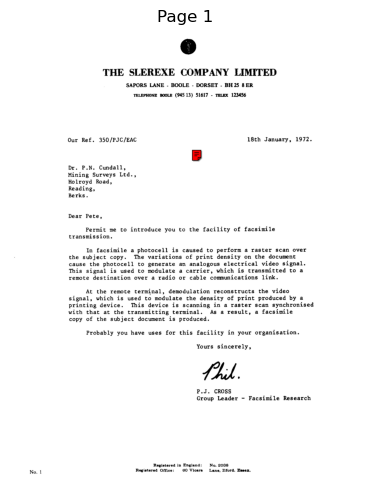

Image quality check complete!
If the images look blurry or text is hard to read, try increasing the DPI value.


In [30]:
import matplotlib.pyplot as plt
from pdf2image import convert_from_path
import numpy as np

def view_pdf_images(file_path, dpi=3000):
    """
    Extract and display all images from a PDF file
    
    Args:
        file_path (str): Path to the PDF file
        dpi (int): DPI for image extraction (higher = better quality but larger images)
    """
    print(f"Converting PDF to images with DPI={dpi}...")
    
    # Convert PDF to images
    images = convert_from_path(file_path, dpi=dpi)
    
    print(f"Successfully extracted {len(images)} images from the PDF")
    
    # Display image information
    for i, img in enumerate(images):
        width, height = img.size
        print(f"Image {i+1}: Size={width}x{height} pixels, Mode={img.mode}")
    
    # Create a figure to display the images
    n_images = len(images)
    if n_images == 0:
        print("No images found in the PDF")
        return
    
    # Determine grid size
    cols = min(3, n_images)  # Maximum 3 columns
    rows = int(np.ceil(n_images / cols))
    
    # Create figure with appropriate size
    plt.figure(figsize=(5*cols, 5*rows))
    
    # Display each image
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i+1)
        plt.imshow(np.array(img))
        plt.title(f"Page {i+1}")
        plt.axis('off')  # Hide axes
    
    plt.tight_layout()
    plt.show()
    
    print("Image quality check complete!")
    print("If the images look blurry or text is hard to read, try increasing the DPI value.")

if __name__ == "__main__":
    file_path = "scaned_pdf.pdf"
    # You can adjust DPI for higher quality images (e.g., 300, 450, 600)
    view_pdf_images(file_path, dpi=500)

In [1]:
import pandas as pd
import boto3
import json
import io
import tempfile
from botocore.exceptions import ClientError

def initialize_aws_clients(region_name):
    """
    Initialize AWS Bedrock runtime and S3 clients
    
    Args:
        region_name (str): AWS region name
    
    Returns:
        tuple: Bedrock runtime client and S3 client
    """
    try:
        # Initialize Bedrock runtime client
        bedrock_runtime = boto3.client('bedrock-runtime', region_name=region_name)
        
        # Initialize S3 client
        s3_client = boto3.client('s3', region_name=region_name)
        
        return bedrock_runtime, s3_client
    
    except Exception as e:
        print(f"Error initializing AWS clients: {e}")
        raise

def read_excel_sheets(file_path):
    """
    Read all sheets from Excel file and extract rows with robust handling
    
    Args:
        file_path (str): Path to the Excel file
    
    Returns:
        dict: A dictionary where keys are sheet names and values are list of row dictionaries
    """
    try:
        # Read all sheets using ExcelFile object
        xls = pd.ExcelFile(file_path)
        
        # Dictionary to store data from all sheets
        all_sheets_data = {}
        
        # Iterate through all sheet names
        for sheet_name in xls.sheet_names:
            # Read each sheet with flexible options
            df = pd.read_excel(
                file_path, 
                sheet_name=sheet_name,
                header=None,  # Don't assume first row is header
                na_values=['', 'NA', 'N/A', 'NaN']  # Additional NA value handling
            )
            
            # Remove completely empty rows
            df = df.dropna(how='all')
            
            # Create a list to store processed rows for this sheet
            rows_data = []
            
            # Iterate through rows
            for index, row in df.iterrows():
                # Create a dictionary for each row
                row_dict = {}
                
                # Process each column
                for col_index, value in enumerate(row):
                    # Skip NaN or None values, use meaningful column identifier
                    if pd.notna(value):
                        # Use column index as key or create a more meaningful key
                        key = f"Column_{col_index+1}"
                        row_dict[key] = str(value).strip()
                
                # Only add non-empty rows
                if row_dict:
                    rows_data.append(row_dict)
            
            # Add this sheet's data to the all_sheets_data dictionary
            all_sheets_data[sheet_name] = rows_data
        
        return all_sheets_data
    
    except Exception as e:
        print(f"Error reading Excel file: {e}")
        return None

def invoke_llm(bedrock_runtime, prompt, model_id="anthropic.claude-3-haiku-20240307-v1:0"):
    """
    Invoke Claude 3 Haiku model through Bedrock
    
    Args:
        bedrock_runtime: Bedrock runtime client
        prompt (str): Prompt to send to the LLM
        model_id (str): ID of the model to invoke
    
    Returns:
        str: Model's response text
    """
    # Format the request payload using the model's native structure
    native_request = {
        "anthropic_version": "bedrock-2023-05-31",
        "max_tokens": 4000,
        "temperature": 0.5,
        "messages": [
            {
                "role": "user",
                "content": [{"type": "text", "text": prompt}]
            }
        ]
    }

    try:
        # Invoke the model with the request
        response = bedrock_runtime.invoke_model(
            modelId=model_id, 
            body=json.dumps(native_request)
        )
        
        # Parse the response
        model_response = json.loads(response["body"].read())
        response_text = model_response["content"][0]["text"]
        return response_text
    
    except (ClientError, Exception) as e:
        print(f"ERROR: Can't invoke '{model_id}'. Reason: {e}")
        raise


def print_processed_results(results):
    """
    Print detailed results from processed Excel file
    
    Args:
        results (dict): Processed results from Excel file
    """
    print("\n===== DETAILED RESULTS =====")
    for sheet_name, batches in results.items():
        print(f"\nSHEET: {sheet_name}")
        for batch_name, batch_data in batches.items():
            print(f"\n  {batch_name}:")
            
            # Try to parse the batch data as JSON
            try:
                # Parse the JSON string into a Python object
                parsed_batch = json.loads(batch_data)
                
                # Check if it's a list (array of rows)
                if isinstance(parsed_batch, list):
                    print(f"    Contains {len(parsed_batch)} rows")
                    
                    # Print each row nicely formatted
                    for row_index, row in enumerate(parsed_batch):
                        print(f"\n    Row {row_index+1}:")
                        for column, value in row.items():
                            print(f"      {column}: {value}")
                else:
                    # If not a list, print the raw data
                    print(f"    Data is not a list: {batch_data}")
                    
            except json.JSONDecodeError:
                # If not valid JSON, print the raw text
                print(f"    Unable to parse as JSON. Raw data: {batch_data}")


def main():
    """
    Main function to demonstrate Excel processing
    """
    # S3 bucket information
    BUCKET_NAME = "mara-batch-inference"
    FILE_KEY = "NBEL_MARA (1).xlsx"
    REGION_NAME = "eu-west-1"
    batch_size=20

    try:
        # Process Excel file from S3
        bedrock_runtime, s3_client = initialize_aws_clients(REGION_NAME)
        # Trim any leading/trailing whitespace from bucket name and file key
        bucket_name = BUCKET_NAME.strip()
        file_key = FILE_KEY.strip()
        
        # Download file from S3 to memory
        print(f"Downloading {file_key} from {bucket_name}...")
        response = s3_client.get_object(Bucket=bucket_name, Key=file_key)
        file_content = response['Body'].read()
        
        # Create a temporary file to save the Excel content
        with tempfile.NamedTemporaryFile(suffix='.xlsx', delete=False) as temp_file:
            temp_file_path = temp_file.name
            temp_file.write(file_content)

        
        # 1. Read rows from all sheets in Excel
        all_sheets_data = read_excel_sheets(temp_file_path)
        if not all_sheets_data:
            return "Failed to read Excel file"
            
        # Dictionary to store processed results for all sheets
        all_sheets_processed_results = {}


        # Process each sheet
        for sheet_name, rows_data in all_sheets_data.items():
            print(f"\nProcessing sheet: {sheet_name}")


            # Use only the first 15 rows for column name identification
            sample_rows = rows_data[:15] if len(rows_data) > 15 else rows_data
            
            # Prepare prompt for column name identification
            rows_str = "\n\n".join([
                "\n".join([f"{key}: {value}" for key, value in row.items() if value is not None]) 
                for row in sample_rows
            ])
        
            prompt = f"""
            Given the following raw data rows, identify the most accurate column names by studying the data:
        
            {rows_str}
        
            Please provide the most appropriate column names based on the data. If you did not find any column names, say "no column names"
            Return the column names as shown in the example 
            
            expected column names:  ["First Name", "Location", "Employee ID"]
            """
            
            # Invoke LLM to identify column names
            column_names = invoke_llm(bedrock_runtime, prompt)
            
            print(f"Identified Column Names for {sheet_name} (using first 15 rows):", column_names)


            # Initialize dictionary to store processed batches
            processed_results = {}
            
            for i in range(0, len(rows_data), batch_size):
                # Get batch of rows
                batch = rows_data[i:i+batch_size]
                print(f"Processing batch {i//batch_size + 1} of {(len(rows_data) + batch_size - 1) // batch_size}")
                
                batch_prompt = f"""  
                TASK: Extract and parse ALL data from these Excel rows, mapping each data point to its appropriate column names.
                
                INPUT:
                - Column Names: {column_names}
                - Rows Data: {batch}
                
                REQUIREMENTS:
                1. Parse and extract EVERY piece of data from ALL provided rows
                2. Match each data point to the most relevant column name
                3. Preserve the original data values without modification
                4. Ensure no data is lost or omitted during extraction
                5. Handle any special characters, numbers, and text formats appropriately
                
                OUTPUT:
                Provide a complete JSON array where each element represents a row:
                - Each row is a JSON object
                - Each key in the object is a column name
                - Each value is the corresponding data from that row
                - All data points are accounted for
                
                The output should be a valid JSON array with this structure:
                [
                  {{
                    "column_name_1": "data_point_1",
                    "column_name_2": "data_point_2",
                    "column_name_3": "data_point_3"
                  }},
                  {{
                    "column_name_1": "data_point_4",
                    "column_name_2": "data_point_5",
                    "column_name_3": "data_point_6"
                  }},
                  ...
                ]            
                
                CRITICAL:
                - Return ONLY the raw JSON array with no introductory text or explanations
                - Your primary objective is to ensure 100% data extraction for ALL rows
                - No information should be lost in the parsing process
                """
        
                # Invoke LLM for batch processing
                batch_response = invoke_llm(bedrock_runtime, batch_prompt)
                
                # Add batch response to processed batches using batch index as key
                processed_results[f"batch_{i//batch_size + 1}"] = batch_response
            
            # Store results for this sheet
            all_sheets_processed_results[sheet_name] = processed_results
        
        # Print detailed results
        print_processed_results(all_sheets_processed_results)
    
    except Exception as e:
        print(f"Error during processing: {str(e)}")

if __name__ == "__main__":
    main()


Processing sheet: Sheet1
Identified Column Names for Sheet1 (using first 15 rows): Based on the provided data, the most appropriate column names would be:

1. Risk Area
2. Question
3. Subquestion
4. NBEL Answer
Processing batch 1 of 20
Processing batch 2 of 20
Processing batch 3 of 20
Processing batch 4 of 20
Processing batch 5 of 20
Processing batch 6 of 20
Processing batch 7 of 20
Processing batch 8 of 20
Processing batch 9 of 20
Processing batch 10 of 20
Processing batch 11 of 20
Processing batch 12 of 20
Processing batch 13 of 20
Processing batch 14 of 20
Processing batch 15 of 20
Processing batch 16 of 20
Processing batch 17 of 20
Processing batch 18 of 20
Processing batch 19 of 20
Processing batch 20 of 20

===== DETAILED RESULTS =====

SHEET: Sheet1

  batch_1:
    Contains 19 rows

    Row 1:
      Risk Area: Insider Trading Risk Assessment
      Question: How do your controls identify and manage potential receipt of inside information through market soundings / wall crossings

In [7]:
import pandas as pd
import boto3
import json
import io
import tempfile
from botocore.exceptions import ClientError

class ExcelDataProcessor:
    def __init__(self, region_name='eu-west-1'):
        """
        Initialize AWS Bedrock runtime client for LLM
        """
        # Initialize Bedrock runtime client
        self.bedrock_runtime = boto3.client('bedrock-runtime', region_name=region_name)
        # Initialize S3 client
        self.s3_client = boto3.client('s3', region_name=region_name)
        # Save region name
        self.region_name = region_name

    def read_excel_sheets(self, file_path):
        """
        Read all sheets from Excel file and extract rows with robust handling
        
        Returns:
        dict: A dictionary where keys are sheet names and values are list of row dictionaries
        """
        try:
            # Read all sheets using ExcelFile object
            xls = pd.ExcelFile(file_path)
            
            # Dictionary to store data from all sheets
            all_sheets_data = {}
            
            # Iterate through all sheet names
            for sheet_name in xls.sheet_names:
                # Read each sheet with flexible options
                df = pd.read_excel(
                    file_path, 
                    sheet_name=sheet_name,
                    header=None,  # Don't assume first row is header
                    na_values=['', 'NA', 'N/A', 'NaN']  # Additional NA value handling
                )
                
                # Remove completely empty rows
                df = df.dropna(how='all')
                
                # Create a list to store processed rows for this sheet
                rows_data = []
                
                # Iterate through rows
                for index, row in df.iterrows():
                    # Create a dictionary for each row
                    row_dict = {}
                    
                    # Process each column
                    for col_index, value in enumerate(row):
                        # Skip NaN or None values, use meaningful column identifier
                        if pd.notna(value):
                            # Use column index as key or create a more meaningful key
                            key = f"Column_{col_index+1}"
                            row_dict[key] = str(value).strip()
                    
                    # Only add non-empty rows
                    if row_dict:
                        rows_data.append(row_dict)
                
                # Add this sheet's data to the all_sheets_data dictionary
                all_sheets_data[sheet_name] = rows_data
            
            return all_sheets_data
    
        except Exception as e:
            print(f"Error reading Excel file: {e}")
            return None

    def invoke_llm(self, prompt):
        """
        Invoke Claude 3 Haiku model through Bedrock
        """
        model_id = "anthropic.claude-3-haiku-20240307-v1:0"
        
        # Format the request payload using the model's native structure
        native_request = {
            "anthropic_version": "bedrock-2023-05-31",
            "max_tokens": 4000,
            "temperature": 0.5,
            "messages": [
                {
                    "role": "user",
                    "content": [{"type": "text", "text": prompt}]
                }
            ]
        }

        try:
            # Invoke the model with the request
            response = self.bedrock_runtime.invoke_model(
                modelId=model_id, 
                body=json.dumps(native_request)
            )
            
            # Parse the response
            model_response = json.loads(response["body"].read())
            response_text = model_response["content"][0]["text"]
            return response_text
        
        except (ClientError, Exception) as e:
            print(f"ERROR: Can't invoke '{model_id}'. Reason: {e}")
            raise

    def identify_column_names(self, rows_data):
        """
        Use LLM to identify column names from the first 15 rows of raw row data
        """
        # Use only the first 15 rows for column name identification
        sample_rows = rows_data[:15] if len(rows_data) > 15 else rows_data
        
        # Prepare prompt for column name identification
        rows_str = "\n\n".join([
            "\n".join([f"{key}: {value}" for key, value in row.items() if value is not None]) 
            for row in sample_rows
        ])

        
        prompt = f"""
        Given the following raw data rows, identify the most accurate column names by studying the data:

        {rows_str}

        Please provide the most appropriate column names based on the data. If you did not find any column names, say "no column names"
        Return the column names as shown in the example 
        
        expected column names:  ["First Name", "Location", "Employee ID"]
        """
        
        # Invoke LLM to identify column names
        column_names_response = self.invoke_llm(prompt)
        
        return column_names_response

    def process_rows_in_batches(self, rows_data, column_names, batch_size=20):
        """
        Process rows in batches using LLM
        """
        # Initialize dictionary to store processed batches
        processed_batches = {}
        
        for i in range(0, len(rows_data), batch_size):
            # Get batch of rows
            batch = rows_data[i:i+batch_size]
            print(f"Processing batch {i//batch_size + 1} of {(len(rows_data) + batch_size - 1) // batch_size}")
            
            batch_prompt = f"""  
            TASK: Extract and parse ALL data from these Excel rows, mapping each data point to its appropriate column names.
            
            INPUT:
            - Column Names: {column_names}
            - Rows Data: {batch}
            
            REQUIREMENTS:
            1. Parse and extract EVERY piece of data from ALL provided rows
            2. Match each data point to the most relevant column name
            3. Preserve the original data values without modification
            4. Ensure no data is lost or omitted during extraction
            5. Handle any special characters, numbers, and text formats appropriately
            
            OUTPUT:
            Provide a complete JSON array where each element represents a row:
            - Each row is a JSON object
            - Each key in the object is a column name
            - Each value is the corresponding data from that row
            - All data points are accounted for
            
            The output should be a valid JSON array with this structure:
            [
              {{
                "column_name_1": "data_point_1",
                "column_name_2": "data_point_2",
                "column_name_3": "data_point_3"
              }},
              {{
                "column_name_1": "data_point_4",
                "column_name_2": "data_point_5",
                "column_name_3": "data_point_6"
              }},
              ...
            ]            
            
            CRITICAL:
            - Return ONLY the raw JSON array with no introductory text or explanations
            - Your primary objective is to ensure 100% data extraction for ALL rows
            - No information should be lost in the parsing process
            """

            # Invoke LLM for batch processing
            batch_response = self.invoke_llm(batch_prompt)
            
            # Add batch response to processed batches using batch index as key
            processed_batches[f"batch_{i//batch_size + 1}"] = batch_response
        
        return processed_batches

    def process_excel(self, file_path):
        """
        Main method to process Excel file with multiple sheets
        """
        # 1. Read rows from all sheets in Excel
        all_sheets_data = self.read_excel_sheets(file_path)
        if not all_sheets_data:
            return "Failed to read Excel file"
        
        # Dictionary to store processed results for all sheets
        all_sheets_processed_results = {}
        
        # Process each sheet
        for sheet_name, rows_data in all_sheets_data.items():
            print(f"\nProcessing sheet: {sheet_name}")
            
            # 2. Identify column names for this sheet (using first 15 rows)
            column_names = self.identify_column_names(rows_data)
            print(f"Identified Column Names for {sheet_name} (using first 15 rows):", column_names)

            # 3. Process rows in batches for this sheet
            processed_results = self.process_rows_in_batches(rows_data, column_names)
            
            # Store results for this sheet
            all_sheets_processed_results[sheet_name] = processed_results
        
        return all_sheets_processed_results

    def process_excel_from_s3(self, bucket_name, file_key):
        """
        Read an Excel file from an S3 bucket and process it
        
        Args:
            bucket_name (str): Name of the S3 bucket
            file_key (str): Key (path) of the Excel file in the bucket
            
        Returns:
            dict: Processed results from all sheets
        """
        try:
            # Trim any leading/trailing whitespace from bucket name and file key
            bucket_name = bucket_name.strip()
            file_key = file_key.strip()
            
            # Download file from S3 to memory
            print(f"Downloading {file_key} from {bucket_name}...")
            response = self.s3_client.get_object(Bucket=bucket_name, Key=file_key)
            file_content = response['Body'].read()
            
            # Create a temporary file to save the Excel content
            with tempfile.NamedTemporaryFile(suffix='.xlsx', delete=False) as temp_file:
                temp_file_path = temp_file.name
                temp_file.write(file_content)
            
            print(f"Excel file downloaded and saved to {temp_file_path}")
            
            # Process Excel file using existing method
            results = self.process_excel(temp_file_path)
            
            return results
            
        except ClientError as e:
            print(f"Error accessing S3: {e}")
            raise
        except Exception as e:
            print(f"Error processing Excel file: {e}")
            raise



In [9]:

# S3 bucket information
BUCKET_NAME = "mara-batch-inference"  # Corrected without the trailing space
# FILE_KEY = "Antler_MARA_2024 (1).xlsx"
FILE_KEY ="NBEL_MARA (1).xlsx"
REGION_NAME = "eu-west-1"  # Change to your region if needed

# Create processor instance
processor = ExcelDataProcessor(region_name=REGION_NAME)

# Process Excel file from S3
try:
    results = processor.process_excel_from_s3(BUCKET_NAME, FILE_KEY)
    
    # Print detailed results for each sheet and batch
    print("\n===== DETAILED RESULTS =====")
    for sheet_name, batches in results.items():
        print(f"\nSHEET: {sheet_name}")
        for batch_name, batch_data in batches.items():
            print(f"\n  {batch_name}:")
            
            # Try to parse the batch data as JSON
            try:
                # Parse the JSON string into a Python object
                parsed_batch = json.loads(batch_data)
                
                # Check if it's a list (array of rows)
                if isinstance(parsed_batch, list):
                    print(f"    Contains {len(parsed_batch)} rows")
                    
                    # Print each row nicely formatted
                    for row_index, row in enumerate(parsed_batch):
                        print(f"\n    Row {row_index+1}:")
                        for column, value in row.items():
                            print(f"      {column}: {value}")
                else:
                    # If not a list, print the raw data
                    print(f"    Data is not a list: {batch_data}")
                    
            except json.JSONDecodeError:
                # If not valid JSON, print the raw text
                print(f"    Unable to parse as JSON. Raw data: {batch_data}")
    
except Exception as e:
    print(f"Error during processing: {str(e)}")

Excel file downloaded and saved to /tmp/tmprx5i8533.xlsx

Processing sheet: Sheet1
Identified Column Names for Sheet1 (using first 15 rows): Based on the provided raw data, the most appropriate column names are:

Column_1: Risk Area
Column_2: Question
Column_3: Subquestion
Column_4: NBEL Answer
Processing batch 1 of 20
Processing batch 2 of 20
Processing batch 3 of 20
Processing batch 4 of 20
Processing batch 5 of 20
Processing batch 6 of 20
Processing batch 7 of 20
Processing batch 8 of 20
Processing batch 9 of 20
Processing batch 10 of 20
Processing batch 11 of 20
Processing batch 12 of 20
Processing batch 13 of 20
Processing batch 14 of 20
Processing batch 15 of 20
Processing batch 16 of 20
Processing batch 17 of 20
Processing batch 18 of 20
Processing batch 19 of 20
Processing batch 20 of 20

===== DETAILED RESULTS =====

SHEET: Sheet1

  batch_1:
    Contains 20 rows

    Row 1:
      Risk Area: Risk Area
      Question: Question
      Subquestion: Subquestion
      NBEL Answer: N

In [21]:
prompt = """ 
Please transcribe all text from this PDF page image exactly as it appears. Maintain the following elements:
- All headings and subheadings in their original format
- Paragraph structures and line breaks
- Bullet points and numbered lists
- Any special formatting or emphasis (bold, italic, underlined text)
- All text content without summarizing, paraphrasing, or omitting any words
-preserve all the relationships between the text and numbers 

FOR Tables and tabular data:
   - Maintain exact structure and all numerical values
   - Clarify row/column relationships

EXCEPTION HANDLING - VISUAL DATA:
When encountering these specific elements:

1. GRAPHS/CHARTS:
   - Identify the chart type and main purpose
   - Extract key data points with their exact values
   - Preserve clear relationships between labels and values
   - explain the all details of graph or chart in the form of text

2. Diagrams WITH TEXT- NUMERICAL CONNECTIONS:
   - Keep labeled components together with their associated numerical data
   - Maintain clear pairing between descriptions and values
   - explain the all details of diagram in the form of text

3. INFOGRAPHICS:
   - Preserve the connection between descriptive elements and their corresponding numerical values
   - Use consistent formatting to show relationships

Transcribe the complete text verbatim, preserving the document's visual hierarchy and organization.
"""

In [7]:
# import pypdfium2 as pdfium
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
import boto3
import base64
import json

from pdf2image import convert_from_path, convert_from_bytes


def convert_pdf_to_images(file_path):
    """
    Convert PDF pages to images.
    
    Args:
        file_path (str): Path to the PDF file
        scale (float, optional): Scale factor for image rendering. Defaults to 300/72.
    
    Returns:
        tuple: A tuple containing:
            - pdf_file (PdfDocument): The PDF document object
            - page_indices (list): List of page indices
            - renderer (list): List of rendered images
    """
    images = convert_from_path(file_path)
    
    return images

def encode_image_to_base64(image):
    """
    Encode an image to base64.
    
    Args:
        image (PIL.Image): Image to encode
    
    Returns:
        str: Base64 encoded image string
    """
    image_byte_array = BytesIO()
    image.save(image_byte_array, format='jpeg', optimize=True)
    image_byte_array.seek(0)
    
    return base64.b64encode(image_byte_array.getvalue()).decode("utf-8")

def prepare_bedrock_request(encoded_image, prompt, model_version="bedrock-2023-05-31", max_tokens=4000):
    """
    Prepare the request body for Bedrock model invocation.
    
    Args:
        encoded_image (str): Base64 encoded image
        prompt (str): Prompt for image analysis
        model_version (str, optional): Bedrock model version. Defaults to "bedrock-2023-05-31".
        max_tokens (int, optional): Maximum tokens for response. Defaults to 4000.
    
    Returns:
        str: JSON formatted request body
    """
    return json.dumps(
        {
            "anthropic_version": model_version,
            "max_tokens": max_tokens,
            "messages": [
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "image",
                            "source": {
                                "type": "base64",
                                "media_type": "image/png",
                                "data": encoded_image,
                            },
                        },
                        {"type": "text", "text": prompt},
                    ],
                }
            ],
        }
    )

def analyze_pdf_images(file_path, model_id, prompt, scale=300/72):
    """
    Analyze PDF pages using Bedrock model.
    
    Args:
        file_path (str): Path to the PDF file
        model_id (str): Bedrock model ID
        prompt (str): Prompt for image analysis
        scale (float, optional): Scale factor for image rendering. Defaults to 300/72.
    
    Returns:
        list: Extracted text from each page
    """
    # Initialize Bedrock client
    client = boto3.client('bedrock-runtime', region_name='eu-west-1')
    
    # Convert PDF to images
    _, page_indices, renderer = convert_pdf_to_images(file_path, scale)
    
    # Store extracted text
    extracted_text = []
    
    # Analyze each page
    for i, image in zip(page_indices, renderer):
        # Encode image to base64
        encoded_image = encode_image_to_base64(image)
        
        # Prepare request body
        body = prepare_bedrock_request(encoded_image, prompt)
        
        # Invoke Bedrock model
        response = client.invoke_model(
            modelId=model_id,
            body=body
        )
        
        # Parse response
        response_body = json.loads(response.get("body").read())
        response_text = response_body['content'][0]['text']
        
        # Store and print response
        extracted_text.append(response_text)
        print(response_text)
        print("*"*100)
    
    return extracted_text



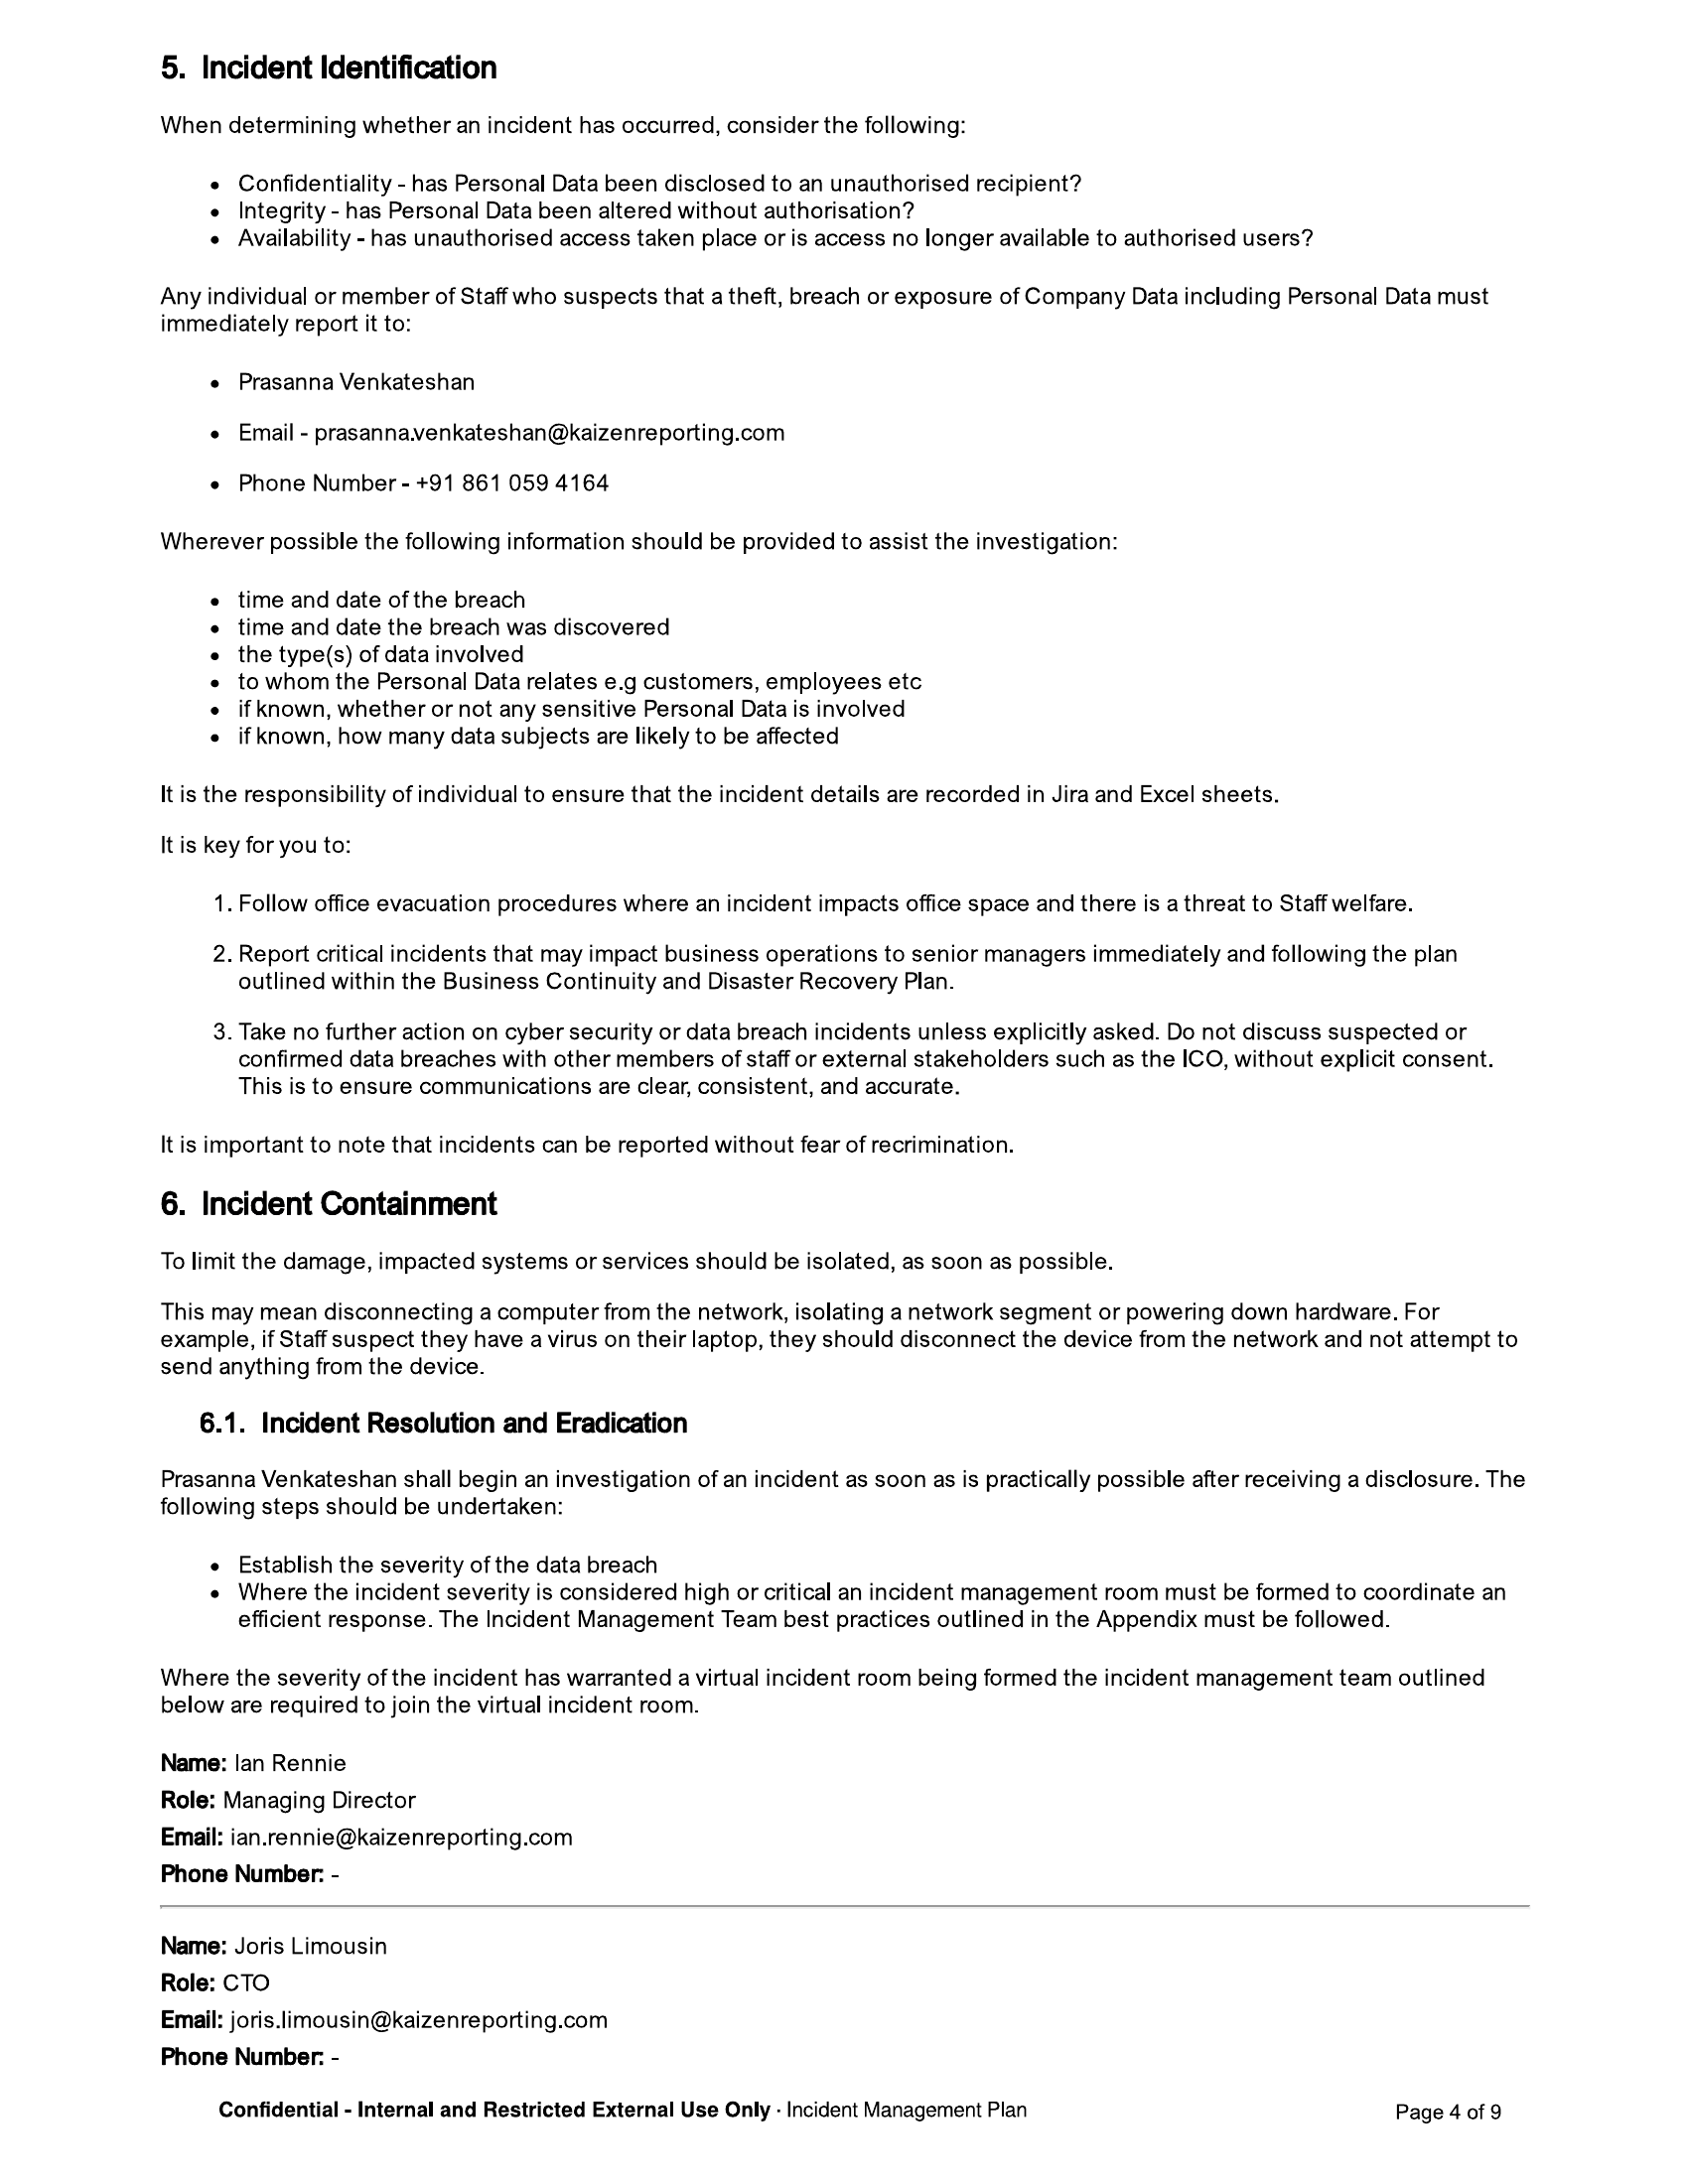

In [20]:
file_path = "scaned_pdf.pdf"
model_id = "anthropic.claude-3-haiku-20240307-v1:0"

extracted_text = analyze_pdf_images(file_path, model_id, prompt, scale=300/72)
